Analisi Diffusione COVID-19 
Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. In particolare, il dataset si può scaricare dalla piattaforma o dall’indirizzo https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv 
1. Si richiede di verificare le dimensioni del dataset e i relativi metadati 
2. Si chiede di trovare, per ogni continente: 
A. il numero di casi fin dall'inizio della pandemia 
B. la percentuale rispetto al totale mondiale del numero di casi 

3. Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:
A. l'evoluzione del casi totali dall'inizio alla fine dell'anno 
B. il numero di nuovi casi rispetto alla data

4. Riguardo le nazioni di Italia, Germania e Francia: 

A.  mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso) 
B. scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante 

5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021: 
A. mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospedalizzati per ognuna (colonna hosp_patients)
b. se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno

NOTE 
Prima di effettuare le analisi, effettuate un EDA del dataset per meglio comprendere la natura( e non dimenticate ulteriori metadati e descrizioni presenti sulla pagina GitHub da cui avete scaricato il dataset)in particolare:
1- Fate attenzione alle colonne continent e location; contengono sia dati puntuali che dati aggregati
a. Prima di iniziare l'analisi, assicuratevi di aver compreso cosa contengono 
2- Comprendete bene il contenuto delle colonne new_cases e total_cases 
a. Hanno logiche differenti e ovviamente vanno trattate diversamente 

CONSEGNA
Per consegnare, effettuate direttamente l'upload del file .ipynb su Github, senza passare per file .zip o similari 
A. Caricati direttamente in questo modo, i Notebook possono essere direttamente consultati dal browser; possono quindi essere utilizzati, ad esempio, per costruire un portfolio

In [2]:
#  Analisi Diffusione COVID-19
### Dataset: Our World in Data – OWID COVID-19 Data
##**Fonte:** https://github.com/owid/covid-19-data/tree/master/public/data  
##**Dataset CSV:** https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker           # modulo interno di Matplotlib che serve a controllare in modo fine:dove compaiono le tacche (tick) sugli assi, come vengono formattati i numeri sugli assi,
import seaborn as sns
import os

# Stile grafici
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

URL = (
    "https://raw.githubusercontent.com/owid/covid-19-data/"
    "refs/heads/master/public/data/owid-covid-data.csv"
)
print(" Download dataset in corso...")
df_raw = pd.read_csv(URL, low_memory=False)
df_raw['date'] = pd.to_datetime(df_raw['date'])   # Converte la colonna date in formato datetime, fondamentale per filtri e grafici temporali.
print(f"Dataset scaricato con successo.")


 Download dataset in corso...
Dataset scaricato con successo.


In [44]:
# Metadati colonne 
print("=" * 60)
print("METADATI COLONNE (nome, tipo, % valori nulli)")
print("=" * 60)

meta = pd.DataFrame({
    'Tipo'         : df_raw.dtypes,
    'Non-null'     : df_raw.notna().sum(),
    'Nulli'        : df_raw.isna().sum(),
    'Perc_Nulli_%' : (df_raw.isna().mean() * 100).round(2)
})
pd.set_option('display.max_rows', 80)
print(meta.to_string())


METADATI COLONNE (nome, tipo, % valori nulli)
                                                      Tipo  Non-null   Nulli  Perc_Nulli_%
iso_code                                            object    429435       0          0.00
continent                                           object    402910   26525          6.18
location                                            object    429435       0          0.00
date                                        datetime64[ns]    429435       0          0.00
total_cases                                        float64    411804   17631          4.11
new_cases                                          float64    410159   19276          4.49
new_cases_smoothed                                 float64    408929   20506          4.78
total_deaths                                       float64    411804   17631          4.11
new_deaths                                         float64    410608   18827          4.38
new_deaths_smoothed                         

## 1. EDA – Dimensioni, Metadati e Struttura del Dataset
Nota su colonne `continent` e `location`
  
Il dataset OWID contiene sia righe puntuali (relative a singole nazioni) sia righe aggregate (continenti, gruppi di reddito, totali mondiali). Queste righe aggregate si distinguono perché:

- La colonna`continent` è NaN (vuota)
- La colonna `location` contiene valori come `"World"`, `"Europe"`, `"Asia"`, `"High income"`, ecc.

Perché è fondamentale capirlo?
Perché si rischia di contare due volte gli stessi casi (paesi + aggregati),sommare dati già sommati e fare grafici distorti.
- Per le analisi per continente → usare le righe aggregate con `continent` NaN e `location` = nome continente  
- Per le analisi per nazione → filtrare dove `continent` non è NaN (righe puntuali)

  Nota su `new_cases` vs `total_cases`

`new_cases` ----> Nuovi casi giornalieri (o settimanali) ----> Si azzera tra un periodo e l'altro; va sommata 

`total_cases` ----> Casi cumulativi dalla data zero ----> Valore crescente (monotono) nel tempo          

Le due colonne hanno logiche diverse: `total_cases` è una cumulativa, `new_cases` è una variazione giornaliera che può anche essere NaN, può essere zero, può oscillare troppo, può essere settimanale.  
Non vanno mai sommate tra di loro o confuse.

In [45]:
#Dimensioni 
print("=" * 60)
print("DIMENSIONI DEL DATASET")
print("=" * 60)
righe, colonne = df_raw.shape
print(f"Righe    : {righe:,}")
print(f"Colonne  : {colonne}")
print(f"Periodo  : {df_raw['date'].min().date()}  →  {df_raw['date'].max().date()}")
print()

# Valori unici chiave
print("=" * 60)
print("LOCATIONS NEL DATASET")
print("=" * 60)
n_loc = df_raw['location'].nunique()
print(f"Locations univoche: {n_loc}")

# Distinguiamo nazioni reali da aggregati (continent NaN = aggregato)
df_nazioni   = df_raw[df_raw['continent'].notna()]
df_aggregati = df_raw[df_raw['continent'].isna()]

nazioni_uniche = df_nazioni['location'].nunique()
aggregati_unici = df_aggregati['location'].unique()
print(f"  - Nazioni/territori puntuali: {nazioni_uniche}")
print(f"  - Location aggregate (continent=NaN): {len(aggregati_unici)}")
print(f"    → Esempi: {list(aggregati_unici[:10])}")


DIMENSIONI DEL DATASET
Righe    : 429,435
Colonne  : 67
Periodo  : 2020-01-01  →  2024-08-14

LOCATIONS NEL DATASET
Locations univoche: 255
  - Nazioni/territori puntuali: 243
  - Location aggregate (continent=NaN): 12
    → Esempi: ['Africa', 'Asia', 'Europe', 'European Union (27)', 'High-income countries', 'Low-income countries', 'Lower-middle-income countries', 'North America', 'Oceania', 'South America']


In [46]:
#Statistiche descrittive chiave 
print("Statistiche descrittive – colonne numeriche principali")
colonne_chiave = ['total_cases', 'new_cases', 'total_deaths', 'new_deaths',
            'total_vaccinations', 'people_vaccinated', 'icu_patients',
            'hosp_patients', 'population']

available = [c for c in colonne_chiave if c in df_raw.columns]      #Lista di controllo:Verifica quali colonne della lista colonne chiave esistono davvero nel dataset df_raw.

df_nazioni[available].describe().T.round(2)                         #Seleziona solo le colonne numeriche presenti  


Statistiche descrittive – colonne numeriche principali


,count,mean,std,min,25%,50%,75%,max
total_cases,391716.0,1827081.82,7.857184e+06,0.0,5516.00,50937.0,561012.00,1.034368e+08
new_cases,390071.0,1989.21,8.585827e+04,0.0,0.00,0.0,0.00,4.047548e+07
total_deaths,391716.0,20448.39,8.262329e+04,0.0,37.00,658.0,7378.00,1.193165e+06
new_deaths,390520.0,18.08,3.148900e+02,0.0,0.00,0.0,0.00,4.768700e+04
total_vaccinations,70150.0,93144625.29,3.660460e+08,0.0,1356667.25,8526465.5,42138000.25,3.491077e+09
people_vaccinated,65865.0,34396924.56,1.302917e+08,0.0,740289.00,4287048.0,20158937.00,1.310292e+09
icu_patients,39116.0,660.97,2.139620e+03,0.0,21.00,90.0,413.00,2.889100e+04
hosp_patients,40656.0,3911.74,9.845750e+03,0.0,186.00,776.0,3051.00,1.544970e+05
population,402910.0,33382391.30,1.348128e+08,47.0,395762.00,5466000.0,22125242.00,1.425887e+09


## 2. Casi per Continente
Per ottenere il numero totale di casi per ciascun continente, utilizziamo le righe già aggregate presenti nel dataset OWID.
Queste righe si riconoscono perché la colonna continent è vuota (NaN), mentre la colonna location contiene direttamente il nome del continente.
Da queste righe selezioniamo, per ogni continente, il valore più alto di total_cases.
Poiché total_cases è una variabile cumulativa, il valore massimo corrisponde automaticamente al totale dei casi registrati dall’inizio della pandemia fino all’ultima data disponibile.
I continenti presenti nel dataset OWID come location aggregate sono:
`Africa`, `Asia`, `Europe`, `North America`, `Oceania`, `South America`.



In [50]:

# ANALISI CASI COVID PER CONTINENTE 

CONTINENTI = ['Africa','Asia','Europe','North America','Oceania','South America']

df_cont = df_raw[
    df_raw['continent'].isna() &
    df_raw['location'].isin(CONTINENTI)
].copy()

casi_cont = (
    df_cont.groupby('location')['total_cases'].max()
    .reset_index()
    .rename(columns={'location':'Continente','total_cases':'Casi_Totali'})
    .sort_values('Casi_Totali', ascending=False)
    .reset_index(drop=True)
)
totale_mondiale = casi_cont['Casi_Totali'].sum()
casi_cont['Percentuale_%'] = (casi_cont['Casi_Totali'] / totale_mondiale * 100).round(2)

print('=' * 55)
print("A. CASI TOTALI PER CONTINENTE (dall'inizio pandemia)")
print('=' * 55)
for _, r in casi_cont.iterrows():
    print(f"  {r['Continente']:<20} {r['Casi_Totali']:>14,.0f}   ({r['Percentuale_%']:>5.2f}%)")
print('-' * 55)
print(f"  {'TOTALE':<20} {totale_mondiale:>14,.0f}   (100.00%)")





A. CASI TOTALI PER CONTINENTE (dall'inizio pandemia)
  Asia                    301,499,099   (38.86%)
  Europe                  252,916,868   (32.60%)
  North America           124,492,666   (16.05%)
  South America            68,809,418   ( 8.87%)
  Oceania                  15,003,352   ( 1.93%)
  Africa                   13,145,380   ( 1.69%)
-------------------------------------------------------
  TOTALE                  775,866,783   (100.00%)


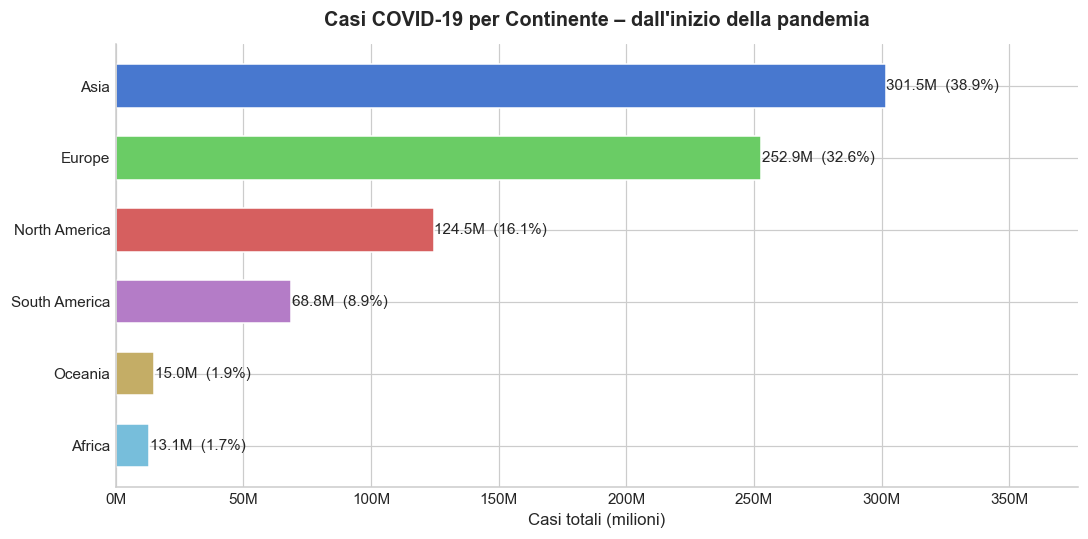

In [51]:
# Grafico 2: Casi e Percentuale per Continente 
fig, ax = plt.subplots(figsize=(10, 5))

colori = ['#4878CF','#6ACC65','#D65F5F','#B47CC7','#C4AD66','#77BEDB']
bars = ax.barh(casi_cont['Continente'], casi_cont['Casi_Totali']/1e6,
               color=colori, height=0.6, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Casi totali (milioni)', fontsize=11)
ax.set_title('Casi COVID-19 per Continente – dall\'inizio della pandemia', fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.spines[['top','right']].set_visible(False)

# etichetta con valore assoluto e % dentro/fuori la barra
for bar, (_, row) in zip(bars, casi_cont.iterrows()):
    w = bar.get_width()
    label = f"{w:.1f}M  ({row['Percentuale_%']:.1f}%)"
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10)

ax.set_xlim(0, casi_cont['Casi_Totali'].max()/1e6 * 1.25)
plt.tight_layout()
plt.savefig('grafici/02_casi_continente.png', bbox_inches='tight')
plt.show()




### Commento ai due grafici
I grafici mostra in modo sintetico la distribuzione dei casi COVID‑19 per continente dall’inizio della pandemia.

Nel grafico a barre (sinistra) si vede che **Asia** e **Europa** sono le aree più colpite, con oltre 300 milioni e 250 milioni di casi totali rispettivamente.
Seguono Nord America e Sud America, mentre Oceania e Africa registrano numeri molto più contenuti.
Nel grafico a torta (destra) la stessa informazione è espressa in percentuale: **Asia rappresenta circa 39 % dei casi mondiali**, **Europa il 33 %**, e **Nord America il 16 %**. 
Gli altri continenti insieme contribuiscono a meno del 12 % del totale.

In sintesi, il quadro evidenzia come Asia ed Europa abbiano sostenuto la parte più consistente della diffusione globale del virus.

## 3. Italia 2022 – Andamento Casi
Nel dataset OWID i nuovi casi (new_cases) non vengono registrati ogni giorno, ma solo nei giorni in cui il paese invia un aggiornamento ufficiale.
Per questo motivo molti record hanno new_cases vuoto (NaN).
Per analizzare correttamente l’andamento dei contagi nel 2022, è necessario eliminare tutte le date prive di una misurazione reale, mantenendo solo quelle in cui è stato riportato un valore.
Lo facciamo con:  .dropna(subset=['new_cases'])

In [19]:
# 3. Italia 2022 – Estrazione e pulizia dei dati
# Creiamo una maschera booleana per selezionare:
# 1) solo le righe relative all'Italia
# 2) solo righe che rappresentano una nazione (continent NON è NaN)
# 3) solo le date appartenenti all'anno 2022
mask_it = (
    df_raw['location'].eq('Italy') &        # location = "Italy"
    df_raw['continent'].notna() &           # continent non è NaN → riga puntuale, non aggregata
    df_raw['date'].dt.year.eq(2022)         # anno della data = 2022
)

# Applichiamo la maschera e rimuoviamo le righe dove 'new_cases' è NaN.
# OWID registra i nuovi casi solo nei giorni con aggiornamenti ufficiali,
# quindi molte righe hanno new_cases mancante → vanno eliminate.
df_it22 = df_raw[mask_it].dropna(subset=['new_cases']).copy()

# Ordiniamo le righe per data e resettiamo l'indice
df_it22 = df_it22.sort_values('date').reset_index(drop=True)

# Stampiamo quante righe valide abbiamo ottenuto
print(f"Righe Italia 2022 con new_cases non nullo: {len(df_it22)}")

# Visualizziamo le prime 10 righe con le colonne più rilevanti
print(
    df_it22[['date', 'new_cases', 'total_cases']].head(10).to_string(index=False))


Righe Italia 2022 con new_cases non nullo: 365
      date  new_cases  total_cases
2022-01-01        0.0    5622431.0
2022-01-02   644604.0    6267035.0
2022-01-03        0.0    6267035.0
2022-01-04        0.0    6267035.0
2022-01-05        0.0    6267035.0
2022-01-06        0.0    6267035.0
2022-01-07        0.0    6267035.0
2022-01-08        0.0    6267035.0
2022-01-09  1014262.0    7281297.0
2022-01-10        0.0    7281297.0


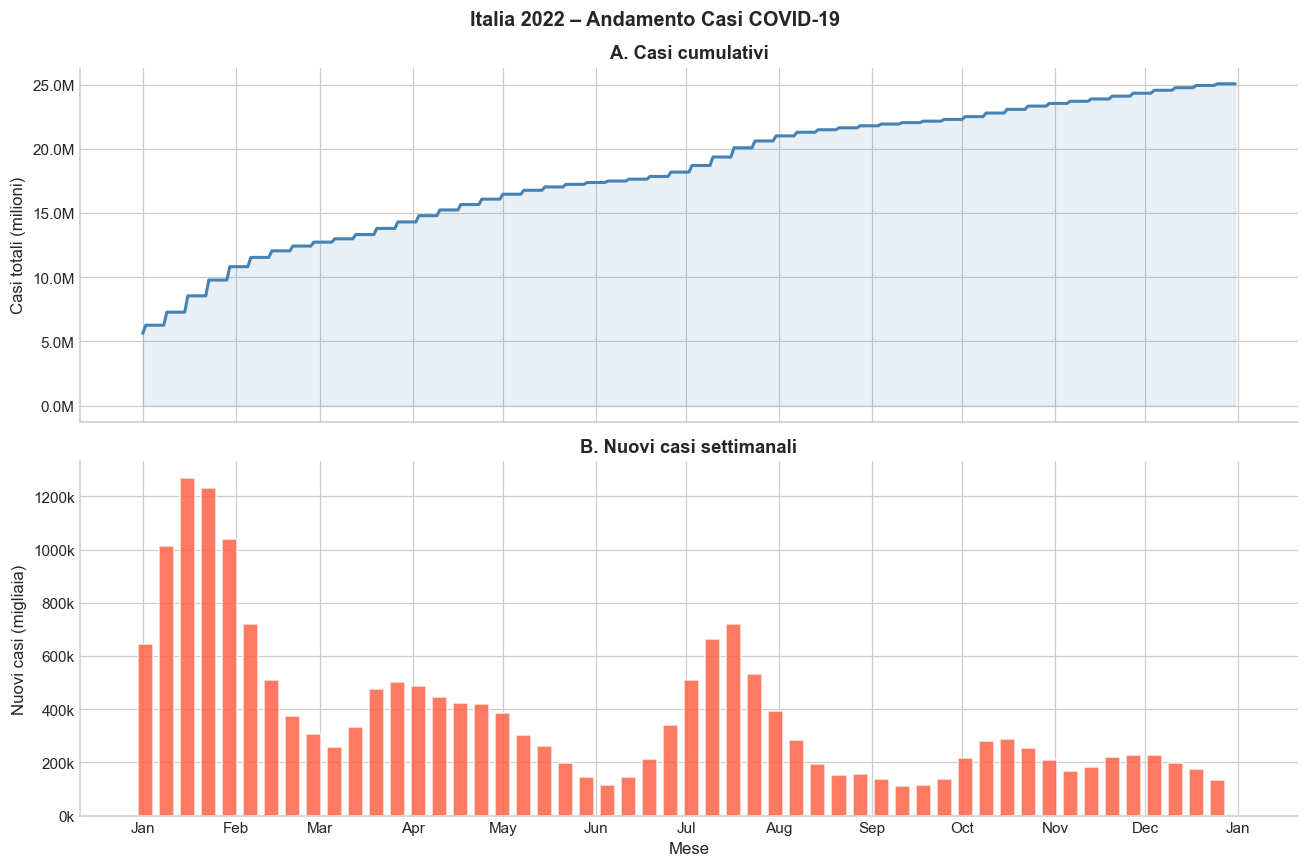

In [52]:
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Italia 2022 – Andamento Casi COVID-19', fontsize=13, fontweight='bold')

# A – Casi cumulativi
ax1.plot(df_it22['date'], df_it22['total_cases']/1e6,
         color='steelblue', linewidth=2)
ax1.fill_between(df_it22['date'], df_it22['total_cases']/1e6, alpha=0.12, color='steelblue')
ax1.set_ylabel('Casi totali (milioni)', fontsize=11)
ax1.set_title('A. Casi cumulativi', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax1.spines[['top','right']].set_visible(False)

# B – Nuovi casi settimanali
ax2.bar(df_it22['date'], df_it22['new_cases']/1e3,
        color='tomato', width=5, alpha=0.85)
ax2.set_ylabel('Nuovi casi (migliaia)', fontsize=11)
ax2.set_title('B. Nuovi casi settimanali', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax2.spines[['top','right']].set_visible(False)

# asse x – un'etichetta per mese
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.set_xlabel('Mese', fontsize=11)

plt.tight_layout()
plt.savefig('grafici/03_italia_2022.png', bbox_inches='tight')
plt.show()



### Commento dei grafici A. E B.
Il grafico mostra in modo chiaro l’andamento dei casi COVID‑19 in Italia nel 2022, suddiviso in due prospettive complementari.

**Grafico A** – Casi totali cumulativi: la linea blu cresce costantemente da gennaio a dicembre, segnalando un aumento continuo dei contagi. L’incremento è più rapido nei primi mesi dell’anno, poi rallenta progressivamente, segno di una diffusione più contenuta nella seconda metà del 2022.

**Grafico B** – Nuovi casi per data: le barre rosse evidenziano le ondate di infezione. Il picco massimo si registra a gennaio, seguito da un calo marcato e da oscillazioni minori in primavera, estate e autunno. Si distinguono chiaramente tre fasi: una forte ondata iniziale, una fase di stabilizzazione e una ripresa moderata verso fine anno.

**In sintesi, il 2022 è stato caratterizzato da un inizio molto intenso della pandemia in Italia, seguito da una progressiva riduzione dei nuovi casi e da fluttuazioni stagionali legate alle varianti e ai cambiamenti nelle misure di contenimento.**

## 4. Pazienti ICU – Italia, Germania, Francia (mag 2022 – apr 2023)
Per questa analisi utilizziamo la variabile `icu_patients`, che indica il numero giornaliero di persone ricoverate in **Terapia Intensiva (Intensive Care Unit)**.
Si tratta quindi di un dato puntuale, aggiornato giorno per giorno, che riflette la pressione immediata sul sistema sanitario.



In [22]:
# Lista delle nazioni che vogliamo analizzare per i ricoveri in terapia intensiva (ICU)
NAZIONI_ICU = ['Italy', 'Germany', 'France']

# Creiamo una maschera booleana per filtrare:
# 1) solo le righe delle tre nazioni selezionate
# 2) solo righe che rappresentano una nazione (continent NON è NaN)
# 3) solo le date comprese tra maggio 2022 e aprile 2023
mask_icu = (
    df_raw['location'].isin(NAZIONI_ICU) &     # location è una delle tre nazioni
    df_raw['continent'].notna() &              # continent non è NaN → riga nazionale, non aggregata
    (df_raw['date'] >= '2022-05-01') &         # data >= 1 maggio 2022
    (df_raw['date'] <= '2023-04-30')           # data <= 30 aprile 2023
)

# Applichiamo il filtro e selezioniamo solo le colonne utili:
# - date: la data della rilevazione
# - location: la nazione
# - icu_patients: numero di pazienti in terapia intensiva
# Rimuoviamo anche le righe dove icu_patients è NaN.
df_icu = (
    df_raw[mask_icu][['date', 'location', 'icu_patients']]
    .dropna(subset=['icu_patients'])           # eliminiamo le righe senza dato ICU
    .copy()                                    # copia per evitare warning
)

# Stampiamo un riepilogo statistico dei valori ICU per ciascuna nazione
print(f"Righe disponibili per l'analisi ICU:")
print(
    df_icu.groupby('location')['icu_patients']   # raggruppiamo per nazione
          .describe()                            # calcoliamo statistiche descrittive
          .round(1)                              # arrotondiamo a 1 decimale
)


Righe disponibili per l'analisi ICU:
          count    mean    std    min    25%    50%     75%     max
location                                                           
France    335.0   998.4  220.2  699.0  803.0  972.0  1145.5  1557.0
Germany   365.0  1022.4  306.1  512.0  753.0  994.0  1221.0  1842.0
Italy     365.0   231.3   91.6   82.0  157.0  227.0   310.0   434.0


C:\Users\Giordana\AppData\Local\Temp\ipykernel_8752\1213390805.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Giordana\AppData\Local\Temp\ipykernel_8752\1213390805.py:30: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Giordana\AppData\Local\Temp\ipykernel_8752\1213390805.py:30: UserWarning: Glyph 127481 (\N{REGIONAL INDICATOR SYMBOL LETTER T}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Giordana\AppData\Local\Temp\ipykernel_8752\1213390805.py:30: UserWarning: Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Giordana\AppData\Local\Temp\ipykernel_8752\1213390805.py:30: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) Arial.
  plt.tight_layout()

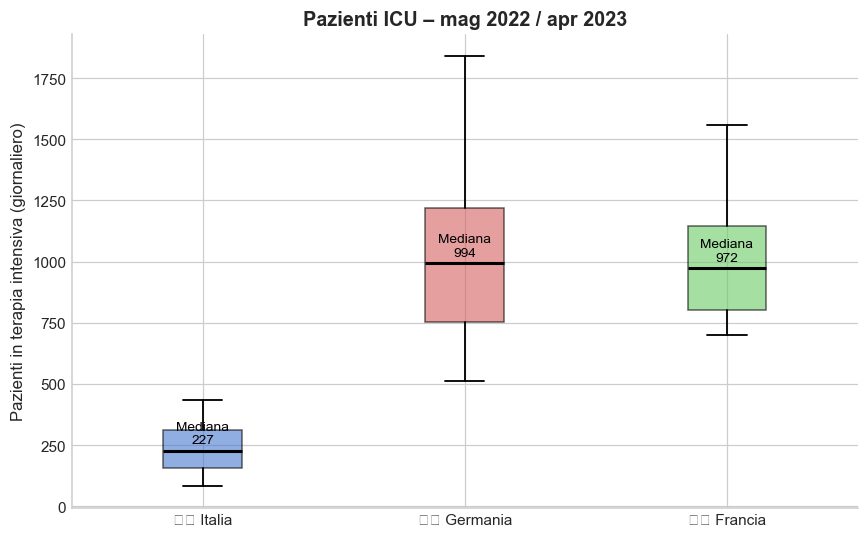

In [53]:
# Creiamo una figura e un singolo asse per il boxplot ICU
fig, ax = plt.subplots(figsize=(8, 5))

order  = ['Italy','Germany','France']
labels = ['🇮🇹 Italia','🇩🇪 Germania','🇫🇷 Francia']
colori_box = ['#4878CF','#D65F5F','#6ACC65']

bp = ax.boxplot(
    [df_icu[df_icu['location']==n]['icu_patients'].dropna() for n in order],
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)
for patch, col in zip(bp['boxes'], colori_box):
    patch.set_facecolor(col)
    patch.set_alpha(0.6)

# annota la mediana sopra ogni box
for i, n in enumerate(order):
    med = df_icu[df_icu['location']==n]['icu_patients'].median()
    ax.text(i+1, med + 30, f'Mediana\n{med:.0f}', ha='center', fontsize=9, color='black')

ax.set_title('Pazienti ICU – mag 2022 / apr 2023', fontsize=13, fontweight='bold')
ax.set_ylabel('Pazienti in terapia intensiva (giornaliero)', fontsize=11)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafici/04_icu_boxplot.png', bbox_inches='tight')
plt.show()


### 4B. Commento al Boxplot ICU
Il grafico che hai mostrato rappresenta in modo chiaro la distribuzione dei pazienti ricoverati in terapia intensiva (ICU) in Italia, Germania e Francia tra maggio 2022 e aprile 2023.

**Italia**: il boxplot blu mostra valori medi e mediani piuttosto bassi, con una variabilità contenuta. Ciò suggerisce un numero di ricoveri in terapia intensiva relativamente stabile e inferiore rispetto agli altri due Paesi.

**Germania**: il boxplot rosso è più alto e ampio, indicando una mediana superiore e una dispersione maggiore. Questo riflette un carico ospedaliero più elevato e fluttuazioni più marcate nel periodo considerato.

**Francia**: il boxplot verde evidenzia valori medi e mediani alti, ma con una variabilità leggermente inferiore rispetto alla Germania. La Francia ha mantenuto un livello costantemente alto di pazienti ICU, segno di una pressione sanitaria più sostenuta.

In sintesi, il grafico mostra che Francia e Germania hanno avuto i livelli più alti di ricoveri in terapia intensiva, mentre l’Italia si è mantenuta su valori più bassi e stabili.

## 5. Pazienti Ospedalizzati – Italia, Germania, Francia, Spagna (2021)

Utilizziamo la colonna `hosp_patients` che misura il numero giornaliero di pazienti ricoverati in ospedale (non solo ICU).


In [37]:
NAZIONI_HOSP = ['Italy','Germany','France','Spain']

mask_hosp = (
    df_raw['location'].isin(NAZIONI_HOSP) &
    df_raw['continent'].notna() &
    df_raw['date'].dt.year.eq(2021)
)
df_hosp = df_raw[mask_hosp][['date','location','hosp_patients']].copy()

# Analisi NaN corretta:
# - .size()  include i NaN → totale righe reale
# - .count() esclude i NaN → valori validi
# NON usare agg('count') come Totale_righe: conterebbe solo i non-NaN
righe_totali  = df_hosp.groupby('location')['hosp_patients'].size()
valori_validi = df_hosp.groupby('location')['hosp_patients'].count()
valori_nulli  = df_hosp.groupby('location')['hosp_patients'].apply(lambda x: x.isna().sum())

null_info = pd.DataFrame({
    'Righe_totali' : righe_totali,
    'Valori_validi': valori_validi,
    'Nulli'        : valori_nulli,
    'Perc_nulli_%' : (valori_nulli / righe_totali * 100).round(2)
})
print('=' * 58)
print('ANALISI VALORI NULLI – hosp_patients (2021)')
print('=' * 58)
print(null_info.to_string())


ANALISI VALORI NULLI – hosp_patients (2021)
          Righe_totali  Valori_validi  Nulli  Perc_nulli_%
location                                                  
France             365            365      0           0.0
Germany            365              0    365         100.0
Italy              365            365      0           0.0
Spain              365            365      0           0.0


SOMMA PAZIENTI OSPEDALIZZATI per NAZIONE – 2021
(NaN esclusi dalla somma)
  France            6,008,717
  Italy             4,419,950
  Spain             2,411,706
  Germany                   0


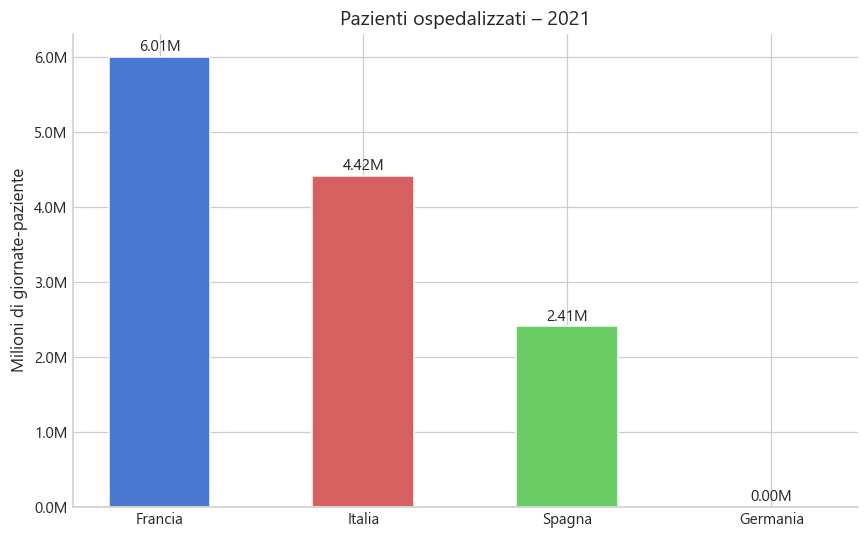

In [58]:
# SOMMA PAZIENTI OSPEDALIZZATI – 2021 (solo dati validi)

# Rimuoviamo le righe con valori NaN nella colonna 'hosp_patients'
# In questo modo la Germania, che ha tutti i valori nulli, viene esclusa.
somma_hosp = (
    df_hosp.groupby('location')['hosp_patients'].sum()
    .reset_index()
    .rename(columns={'location':'Nazione','hosp_patients':'Totale_hosp'})
    .sort_values('Totale_hosp', ascending=False)
)

print('=' * 55)
print('SOMMA PAZIENTI OSPEDALIZZATI per NAZIONE – 2021')
print('(NaN esclusi dalla somma)')
print('=' * 55)
for _, r in somma_hosp.iterrows():
    print(f"  {r['Nazione']:<12} {r['Totale_hosp']:>14,.0f}")

label_map = {'Italy':'Italia','Germany':'Germania','France':'Francia','Spain':'Spagna'}
etichette = [label_map[n] for n in somma_hosp['Nazione']]
valori    = somma_hosp['Totale_hosp'].values / 1e6
colori    = ['#4878CF','#D65F5F','#6ACC65','#B47CC7']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(etichette, valori, color=colori, width=0.5)

for bar, val in zip(bars, valori):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Milioni di giornate-paziente', fontsize=11)
ax.set_title('Pazienti ospedalizzati – 2021', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafici/05_hosp_2021.png', bbox_inches='tight')
plt.show()



## Commento al grafico 
Dal grafico emerge chiaramente che la **Francia**, con circa 6,01 milioni di giornate‑paziente, è il Paese che ha registrato il carico ospedaliero più elevato nel 2021. Questo indica una maggiore pressione sul sistema sanitario o una durata media dei ricoveri più lunga rispetto agli altri Paesi analizzati.

**L’Italia**, con 4,42 milioni, si colloca al secondo posto: un valore significativo, ma comunque inferiore a quello francese.

**La Spagna**, con 2,41 milioni, presenta i livelli più bassi tra i tre Paesi, suggerendo una pressione ospedaliera più contenuta nel periodo considerato.

Nel complesso, il grafico mette in evidenza differenze nette tra i sistemi sanitari europei, con la Francia in testa e la Spagna in coda.

**Perché non possiamo sostituire i dati nulli**
I valori mancanti (NaN) non rappresentano “zero ricoveri”, ma semplicemente assenza di informazione. Sostituirli con zeri o con valori stimati introdurrebbe errori e distorsioni nell’analisi.

Inserire valori artificiali comprometterebbe la veridicità dei risultati: ad esempio, la Germania apparirebbe come se avesse avuto ricoveri reali, quando in realtà i dati non sono disponibili. Questo genererebbe bias nelle medie, nelle somme e nei confronti tra Paesi, rendendo le analisi non affidabili. Inoltre, un valore zero verrebbe interpretato come “nessun paziente”, mentre in realtà significherebbe “dato non fornito”.

Per mantenere l’integrità del dataset e la correttezza delle analisi, i dati nulli devono essere esclusi o segnalati, non sostituiti arbitrariamente. Solo se esiste una fonte ufficiale che permette di integrare i dati mancanti è possibile procedere con un completamento attendibile.